# 从 PBMC3k 学习 scRNA-seq 全流程

这本 Notebook 使用真实的 10x PBMC3k 未归一化计数，逐步运行与 Snakemake 相同的实现。
从上到下执行，不要先运行后面的格子。每一步请先读它回答的问题，再看输出。

数据：1 位健康供者，2,700 个 PBMC；[10x 来源](https://www.10xgenomics.com/datasets/3-k-pbm-cs-from-a-healthy-donor-1-standard-1-1-0)。
完整代码在 `src/scrna_learn/`，方法解释在 `docs/02_walkthrough.md`。
这份数据用于学习细胞分群，不包含可用于病例对照比较的独立生物学重复。

In [1]:
from pathlib import Path
import os
for key in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMBA_NUM_THREADS']:
    os.environ[key] = '1'
root = Path.cwd()
if not (root / 'pyproject.toml').exists() and (root.parent / 'pyproject.toml').exists():
    root = root.parent
assert (root / 'pyproject.toml').exists(), '请在本仓库中打开 Notebook'
os.chdir(root)
import json
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display, Image
from scrna_learn.common import load_config
from scrna_learn.cli import run_stage
cfg = load_config('config/config.yaml')
cfg['output_dir'] = 'results/notebook_pbmc3k'
out = Path(cfg['output_dir'])
print('Scanpy', sc.__version__)
display(pd.DataFrame([cfg['qc']]).drop(columns='sample_overrides'))

Scanpy 1.11.5


<ipython-input-1-f34c0ea722fb>:20: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print('Scanpy', sc.__version__)


,min_genes,max_genes,max_pct_mt,min_cells_per_gene,mitochondrial_prefix
0,200,2500,5.0,3,MT-


## 1. 输入：细胞 × 基因的矩阵

`ingest` 会校验演示文件的 SHA256，确认整数 UMI，加入样本和供者信息。
`obs` 是逐细胞 metadata；`var` 是逐基因 metadata。先检查细胞数、基因数和原始计数是否合理。

In [2]:
run_stage('ingest', cfg)
counts = sc.read_h5ad(out / 'objects/01_counts.h5ad')
print('cells × genes:', counts.shape)
print('total UMI:', int(counts.X.sum()))
display(counts.obs.head())
display(counts.var.head())

[ingest] start
[ingest] completed in 1.7s
cells × genes: (2700, 32738)
total UMI: 6390631


,barcode,sample_id,donor,condition,batch
AAACATACAACCAC-1::pbmc3k,AAACATACAACCAC-1,pbmc3k,donor1,healthy,batch1
AAACATTGAGCTAC-1::pbmc3k,AAACATTGAGCTAC-1,pbmc3k,donor1,healthy,batch1
AAACATTGATCAGC-1::pbmc3k,AAACATTGATCAGC-1,pbmc3k,donor1,healthy,batch1
AAACCGTGCTTCCG-1::pbmc3k,AAACCGTGCTTCCG-1,pbmc3k,donor1,healthy,batch1
AAACCGTGTATGCG-1::pbmc3k,AAACCGTGTATGCG-1,pbmc3k,donor1,healthy,batch1


,gene_ids,gene_symbol
index,,
MIR1302-10,ENSG00000243485,MIR1302-10
FAM138A,ENSG00000237613,FAM138A
OR4F5,ENSG00000186092,OR4F5
RP11-34P13.7,ENSG00000238009,RP11-34P13.7
RP11-34P13.8,ENSG00000239945,RP11-34P13.8


## 2. 质控：每一个被移除的细胞都有原因

基础指标由 `sc.pp.calculate_qc_metrics` 计算。当前 PBMC 教学阈值是基因数 ≥200 且 <2500、线粒体比例 <5%。
Scrublet 在每个 capture 的未归一化计数上预测双细胞。请检查自动阈值，而不是默认它一定正确。
先看到全部细胞的去留表，再看总体数量。

[qc] start
[qc] completed in 8.2s


,cells
decision,
high_genes,5
high_mito,57
predicted_doublet,31
retained,2607


,cell_id,n_genes_by_counts,total_counts,pct_counts_mt,decision
16,AAAGATCTGGGCAA-1::pbmc3k,552,1348.0,5.934718,high_mito
17,AAAGCAGAAGCCAT-1::pbmc3k,567,1158.0,5.094991,high_mito
74,AACGCCCTGCTTAG-1::pbmc3k,420,1074.0,5.400372,high_mito
88,AACTTGCTACGCTA-1::pbmc3k,900,2336.0,2.654110,predicted_doublet
129,AAGGTCTGGTATGC-1::pbmc3k,351,715.0,5.034965,high_mito
175,AATGTAACGTTTGG-1::pbmc3k,537,1130.0,5.221239,high_mito
182,AATTACGAGTAGCT-1::pbmc3k,997,2712.0,5.457227,high_mito
201,ACACAGACACCTGA-1::pbmc3k,299,551.0,6.170599,high_mito
225,ACATGGTGCAACCA-1::pbmc3k,756,2147.0,2.748021,predicted_doublet
227,ACATGGTGCGTTGA-1::pbmc3k,690,1562.0,5.377721,high_mito


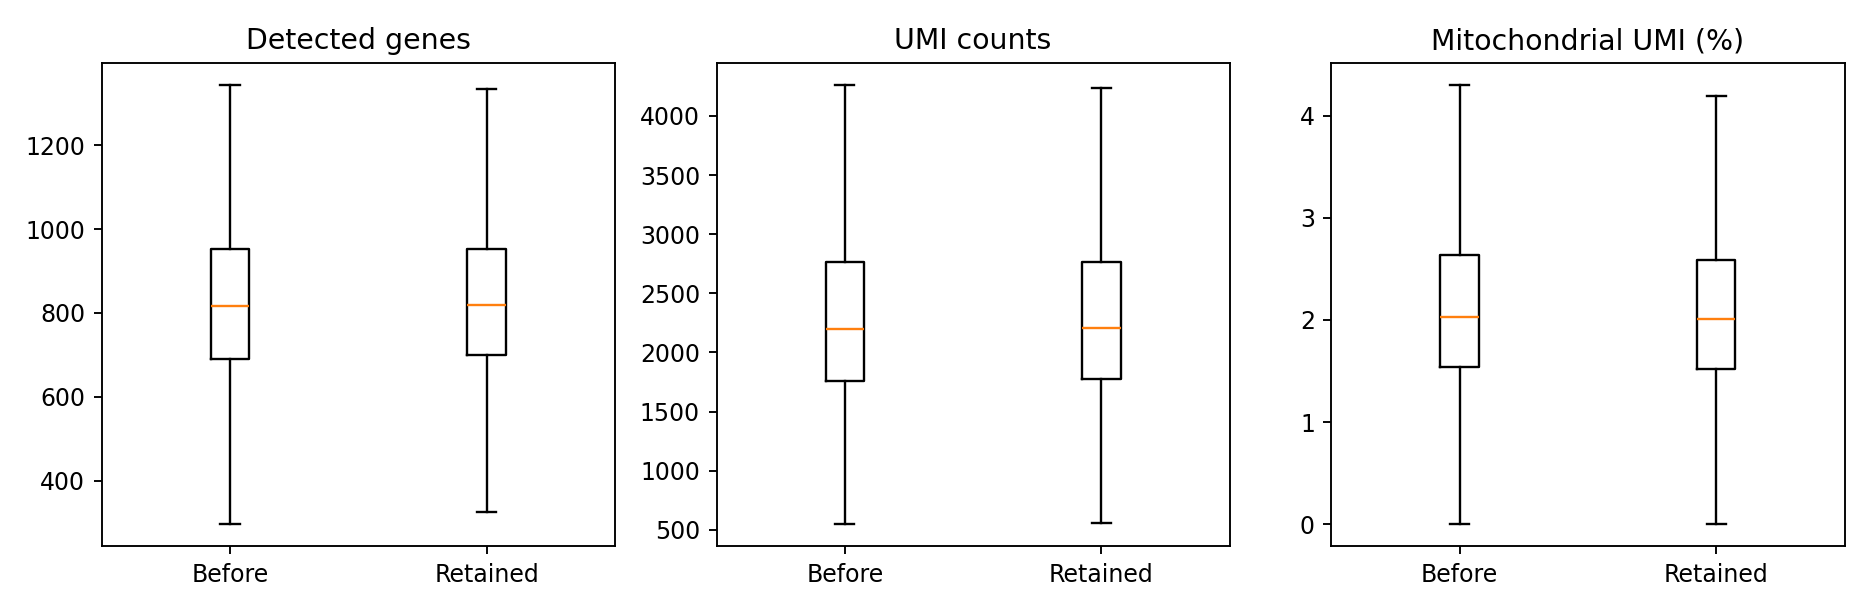

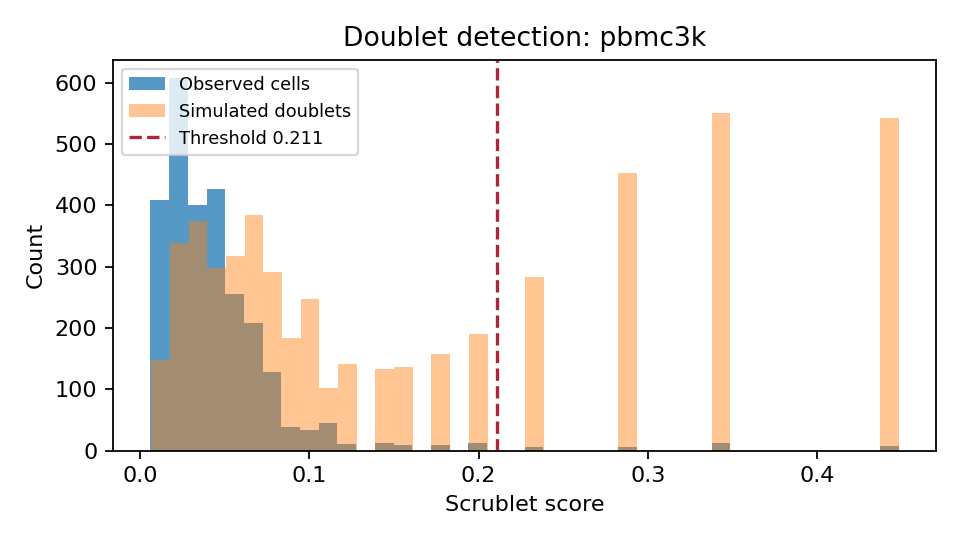

In [3]:
run_stage('qc', cfg)
qc = pd.read_csv(out / 'tables/cell_qc.csv')
display(qc.groupby('decision', dropna=False).size().rename('cells').to_frame())
display(qc.loc[~qc.retained, ['cell_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'decision']].head(10))
display(Image(filename=str(out / 'figures/qc.png')))
for fig in sorted((out / 'figures').glob('doublets_*.png')):
    display(Image(filename=str(fig)))

## 3. 标准化与高变基因

核心运算是 `normalize_total(target_sum=1e4)` 和 `log1p`，原始计数保存在 `layers['counts']`。
这里 `highly_variable_genes(flavor='seurat')` 使用 log 表达；不能与要求 counts 的 `seurat_v3` 混淆。
全对象保留全部通过质控的基因，只有构建 PCA 时使用 HVG 子对象。

[normalize] start
[normalize] completed in 1.6s
保留细胞/基因: (2607, 13611) HVG: 2000
counts 层是否仍为整数: True


,means,dispersions_norm
index,,
TNFRSF4,0.279817,0.661690
CPSF3L,0.386198,2.936998
ATAD3C,0.038698,4.354513
C1orf86,0.679137,0.548166
RER1,0.819070,1.580305
TNFRSF25,0.305208,1.258309
TNFRSF9,0.032521,1.856324
CA6,0.009882,0.498484
CTNNBIP1,0.306723,2.568921


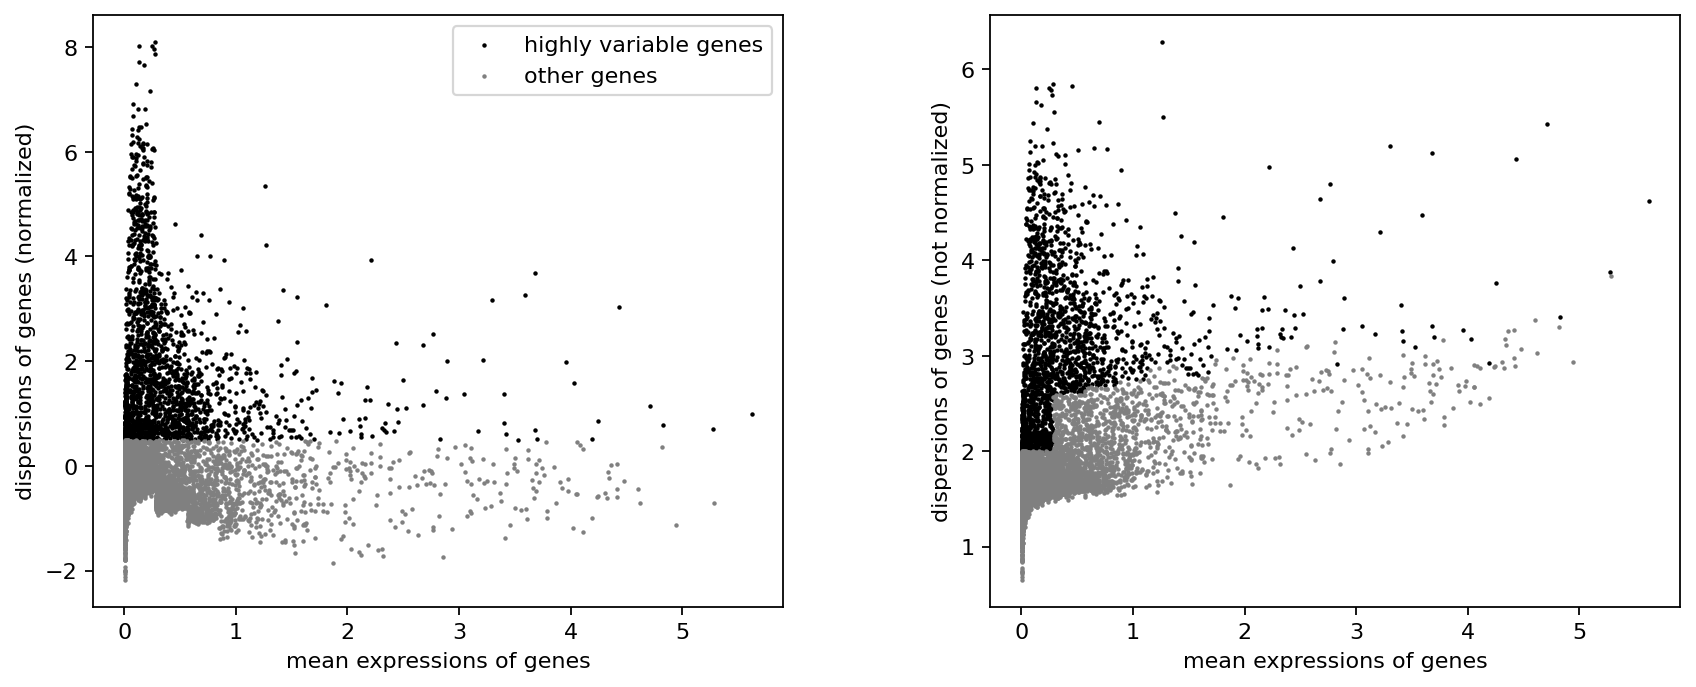

In [4]:
run_stage('normalize', cfg)
a = sc.read_h5ad(out / 'objects/03_normalized.h5ad')
print('保留细胞/基因:', a.shape, 'HVG:', int(a.var.highly_variable.sum()))
print('counts 层是否仍为整数:', np.allclose(a.layers['counts'].data, np.rint(a.layers['counts'].data)))
display(a.var.loc[a.var.highly_variable, ['means', 'dispersions_norm']].head(10))
display(Image(filename=str(out / 'figures/highly_variable_genes.png')))

## 4. PCA、邻居图、Leiden 和 UMAP

PCA 提取主要表达差异；邻居图把相似的细胞联系起来；Leiden 在图上分群；UMAP 用于观察。
当前配置使用 40 个 PC、15 个邻居和 1.0 分辨率。
检查线粒体比例是否与某些群重合。UMAP 岛之间的距离不等同于发育时间。

[embed] start
[embed] completed in 45.5s


/opt/codex/runtimes/codex-primary-runtime/dependencies/python/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


,cells
cluster,
0,453
1,717
2,327
3,207
4,418
5,158
6,279
7,33
8,15


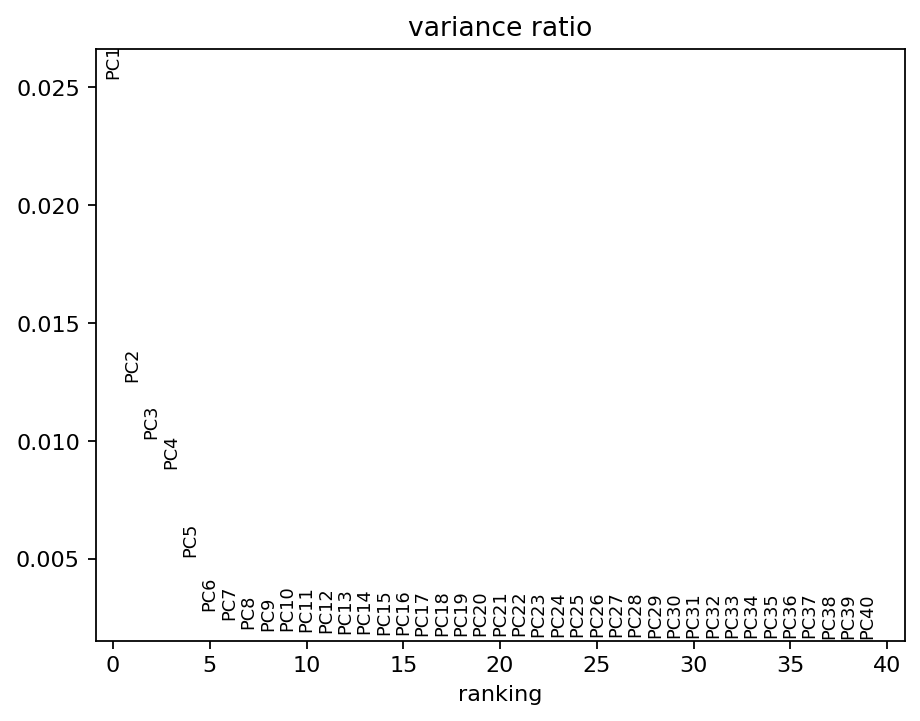

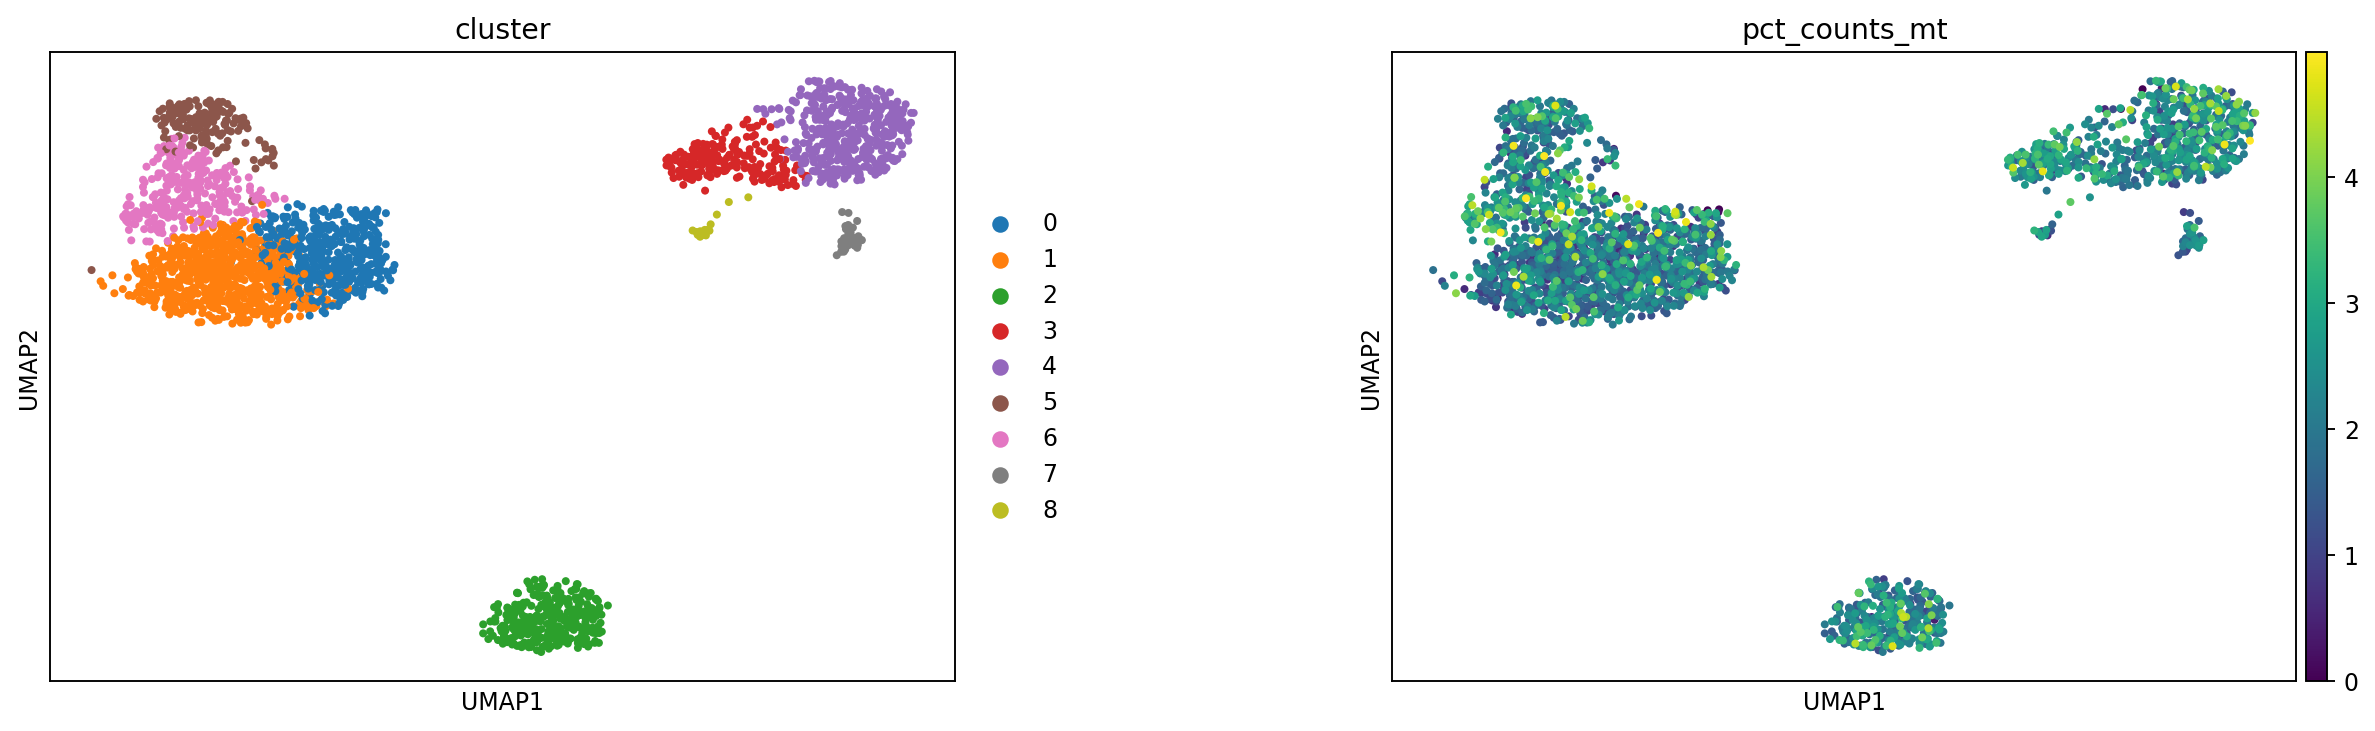

In [5]:
run_stage('embed', cfg)
a = sc.read_h5ad(out / 'objects/04_clustered.h5ad')
display(a.obs.cluster.value_counts().sort_index().rename('cells').to_frame())
display(Image(filename=str(out / 'figures/pca_variance.png')))
display(Image(filename=str(out / 'figures/umap_clusters.png')))

## 5. 找 marker：不是进行疾病差异推断

对每个 cluster 与其余细胞做 Wilcoxon 探索性比较，BH 校正，查看效应量及表达比例。
输入是全基因的 log-normalized 表达，既不是缩放矩阵，也不是只有 HVG 的矩阵。
这些细胞先被用于聚类，再用于 marker 筛选，所以 p 值不能当作独立验证。

In [6]:
run_stage('markers', cfg)
markers = pd.read_csv(out / 'tables/markers_top10.csv')
display(markers.groupby('group').head(3))

[markers] start
[markers] completed in 19.1s


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,RPS12,20.153242,0.845284,2.520493e-90,3.430643e-86,1.000000,0.992108
1,0,RPL32,19.941463,0.684821,1.777856e-88,1.209920e-84,0.997792,0.995357
2,0,RPS27,19.862427,0.847691,8.605015e-88,3.904096e-84,0.997792,0.992572
10,1,LDHB,23.729797,2.129254,1.776434e-124,2.417905e-120,0.953975,0.568254
11,1,LTB,22.794352,2.406642,5.216436e-115,3.550045e-111,0.969317,0.601058
12,1,CD3D,22.125006,2.429429,1.816158e-108,8.239911e-105,0.906555,0.373016
20,2,CD79A,43.664080,7.838329,0.000000e+00,0.000000e+00,0.941896,0.041228
21,2,MS4A1,39.432823,6.450376,0.000000e+00,0.000000e+00,0.862385,0.053509
22,2,TCL1A,35.280178,7.069704,1.182595e-272,5.365433e-269,0.629969,0.021053
30,3,RP11-290F20.3,30.709394,4.904332,4.264134e-207,5.803912e-203,0.763285,0.058333


## 6. 细胞注释：同时看谱系与竞争证据

程序输出候选标签，不将其包装为验证过的分类结果。
例如，NKG7/PRF1 也可以出现在细胞毒 T 细胞中，需要一起看 CD3D/CD3E。
`T/NK unresolved` 提醒你继续检查，不能为了让图好看而强行命名。
点图的大小代表表达细胞比例；颜色是按基因缩放后的平均表达。

[annotate] start
[annotate] completed in 7.0s


,cluster,n_cells,candidate_cell_type,top_panel,runner_up,score,margin,t_lineage_fraction,present_markers,missing_markers,annotation_status
0,0,453,T cells,T cells,Platelets,0.126135,0.160098,0.760486,CD3D;CD3E;IL7R,TRAC,candidate_requires_review
1,1,717,T cells,T cells,Platelets,0.270561,0.309220,0.860530,CD3D;CD3E;IL7R,TRAC,candidate_requires_review
2,2,327,B cells,B cells,Platelets,1.892846,1.927467,0.071865,MS4A1;CD79A;CD79B;CD37,NaN,candidate_requires_review
3,3,207,FCGR3A monocytes,FCGR3A monocytes,CD14 monocytes,1.693670,0.877280,0.099034,FCGR3A;MS4A7;LST1;IFITM3,NaN,candidate_requires_review
4,4,418,CD14 monocytes,CD14 monocytes,FCGR3A monocytes,2.869641,2.360924,0.084928,CD14;LYZ;S100A8;S100A9,NaN,candidate_requires_review
5,5,158,NK cells,NK cells,Platelets,2.509947,2.561202,0.275316,GNLY;NKG7;PRF1;KLRD1,NaN,candidate_requires_review
6,6,279,T/NK unresolved,NK cells,T cells,0.766627,0.627217,0.793907,GNLY;NKG7;PRF1;KLRD1,NaN,candidate_requires_review
7,7,33,Dendritic cells,Dendritic cells,CD14 monocytes,1.646952,0.872292,0.136364,FCER1A;CD1C;CST3;CLEC10A,NaN,candidate_requires_review
8,8,15,Platelets,Platelets,CD14 monocytes,4.463896,4.152407,0.100000,PPBP;PF4;GNG11;SDPR,NaN,candidate_requires_review


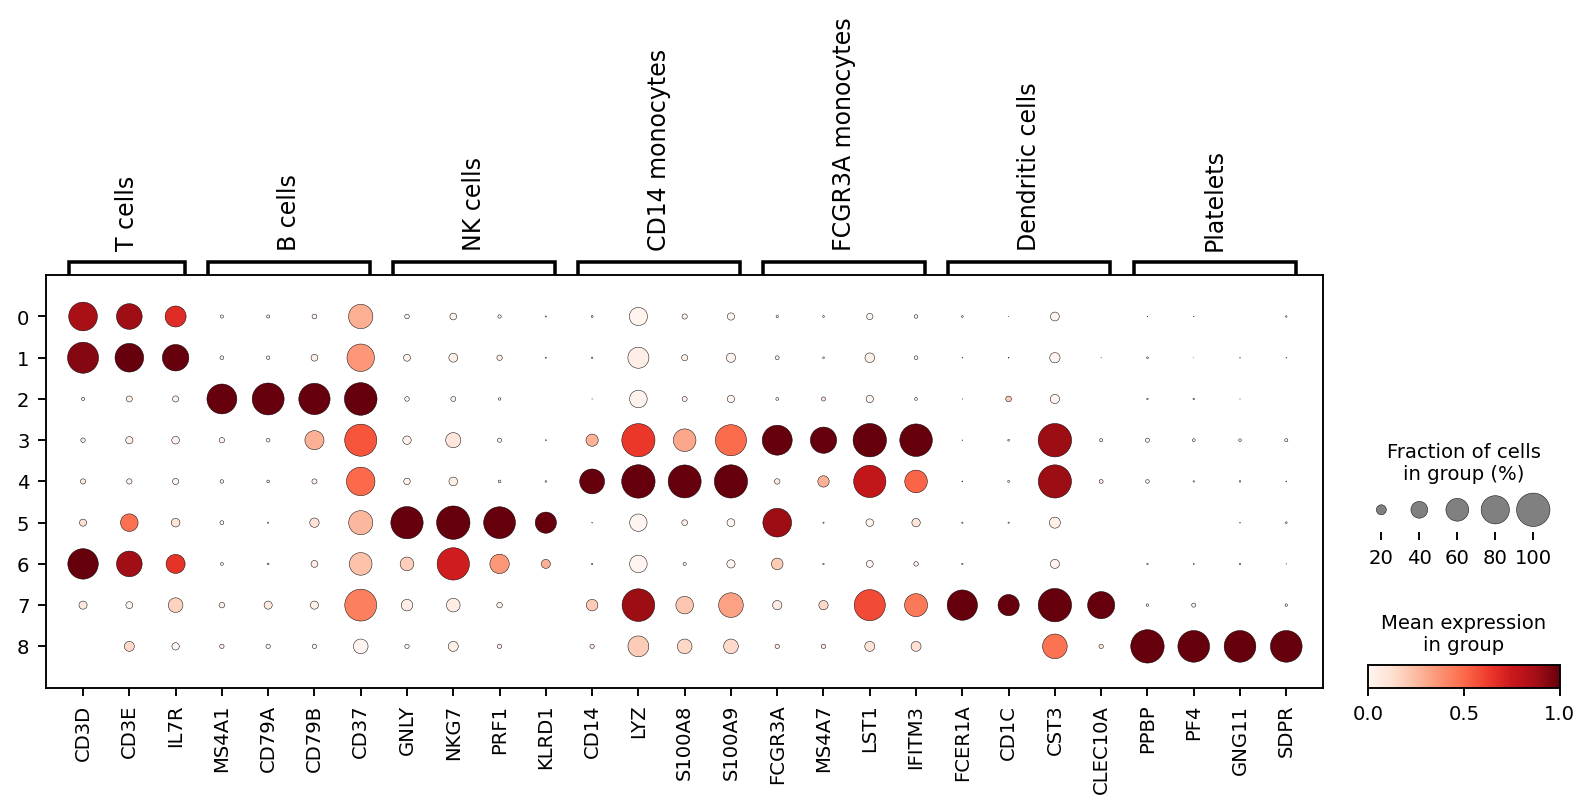

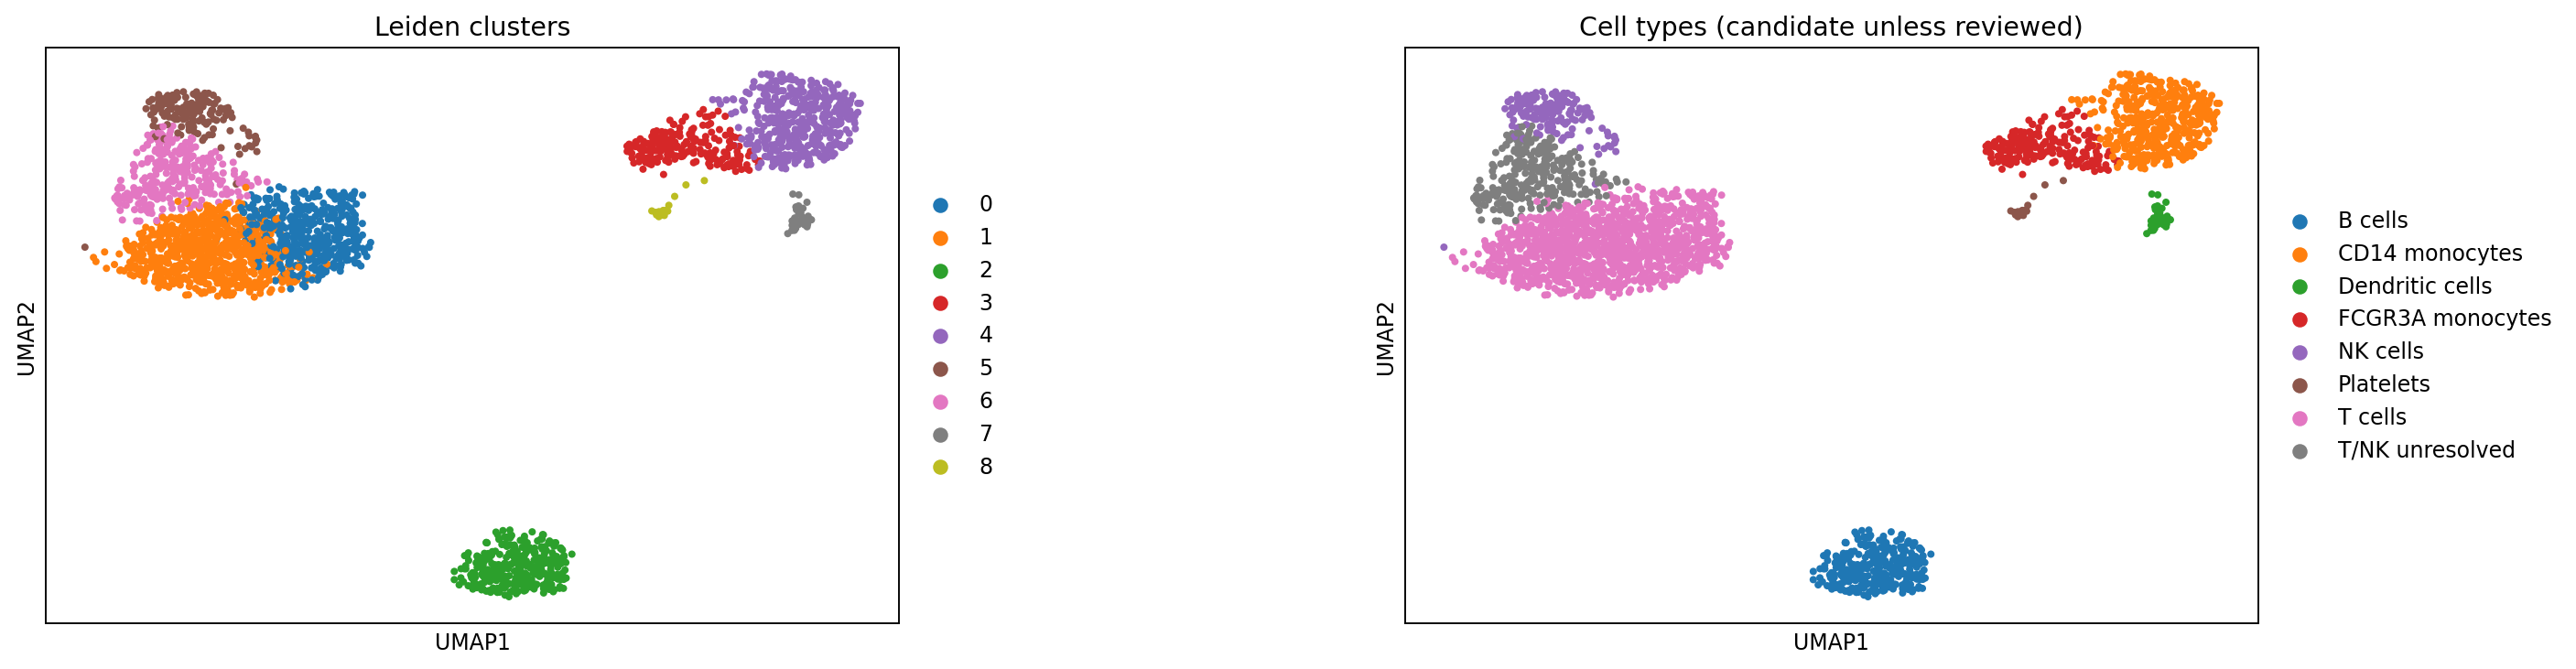

In [7]:
run_stage('annotate', cfg)
evidence = pd.read_csv(out / 'tables/annotation_evidence.csv')
display(evidence)
display(Image(filename=str(out / 'figures/marker_dotplot.png')))
display(Image(filename=str(out / 'figures/umap_celltypes.png')))

## 7. 功能富集

使用固定的 Reactome_2022 人类基因集快照，在本地进行 hypergeometric ORA。
背景是所有受检基因，查询是阳性 marker 前 200 个，校正包含所有符合大小范围的条目。
富集是功能线索，不等同于通路活性或因果机制。

[enrichment] start
[enrichment] completed in 2.7s


,cluster,term,source,overlap,set_size,query_size,universe_size,pvalue,overlap_genes,padj
0,0,Eukaryotic Translation Elongation R-HSA-156842,NaN,66,87,200,13611,4.163205e-107,EEF1A1;EEF1B2;RPL10A;RPL11;RPL12;RPL13A;RPL14;...,6.486273e-104
1,0,Peptide Chain Elongation R-HSA-156902,NaN,65,84,200,13611,1.854377e-106,EEF1A1;RPL10A;RPL11;RPL12;RPL13A;RPL14;RPL18;R...,1.444560e-103
2,0,Nonsense Mediated Decay (NMD) Independent Of E...,NaN,65,90,200,13611,6.144092e-103,PABPC1;RPL10A;RPL11;RPL12;RPL13A;RPL14;RPL18;R...,3.190832e-100
3,0,Viral mRNA Translation R-HSA-192823,NaN,64,87,200,13611,3.448181e-102,RPL10A;RPL11;RPL12;RPL13A;RPL14;RPL18;RPL18A;R...,1.074453e-99
4,0,Selenocysteine Synthesis R-HSA-2408557,NaN,64,87,200,13611,3.448181e-102,RPL10A;RPL11;RPL12;RPL13A;RPL14;RPL18;RPL18A;R...,1.074453e-99
5,1,Eukaryotic Translation Elongation R-HSA-156842,NaN,59,87,200,13611,2.219248e-90,EEF1A1;EEF1B2;RPL10A;RPL11;RPL13A;RPL14;RPL18;...,3.457588e-87
6,1,Peptide Chain Elongation R-HSA-156902,NaN,58,84,200,13611,1.513746e-89,EEF1A1;RPL10A;RPL11;RPL13A;RPL14;RPL18;RPL18A;...,1.179208e-86
7,1,Selenocysteine Synthesis R-HSA-2408557,NaN,57,87,200,13611,7.703414e-86,RPL10A;RPL11;RPL13A;RPL14;RPL18;RPL18A;RPL19;R...,3.000480e-83
8,1,Viral mRNA Translation R-HSA-192823,NaN,57,87,200,13611,7.703414e-86,RPL10A;RPL11;RPL13A;RPL14;RPL18;RPL18A;RPL19;R...,3.000480e-83
9,1,Eukaryotic Translation Termination R-HSA-72764,NaN,57,88,200,13611,2.164055e-85,RPL10A;RPL11;RPL13A;RPL14;RPL18;RPL18A;RPL19;R...,6.743195e-83


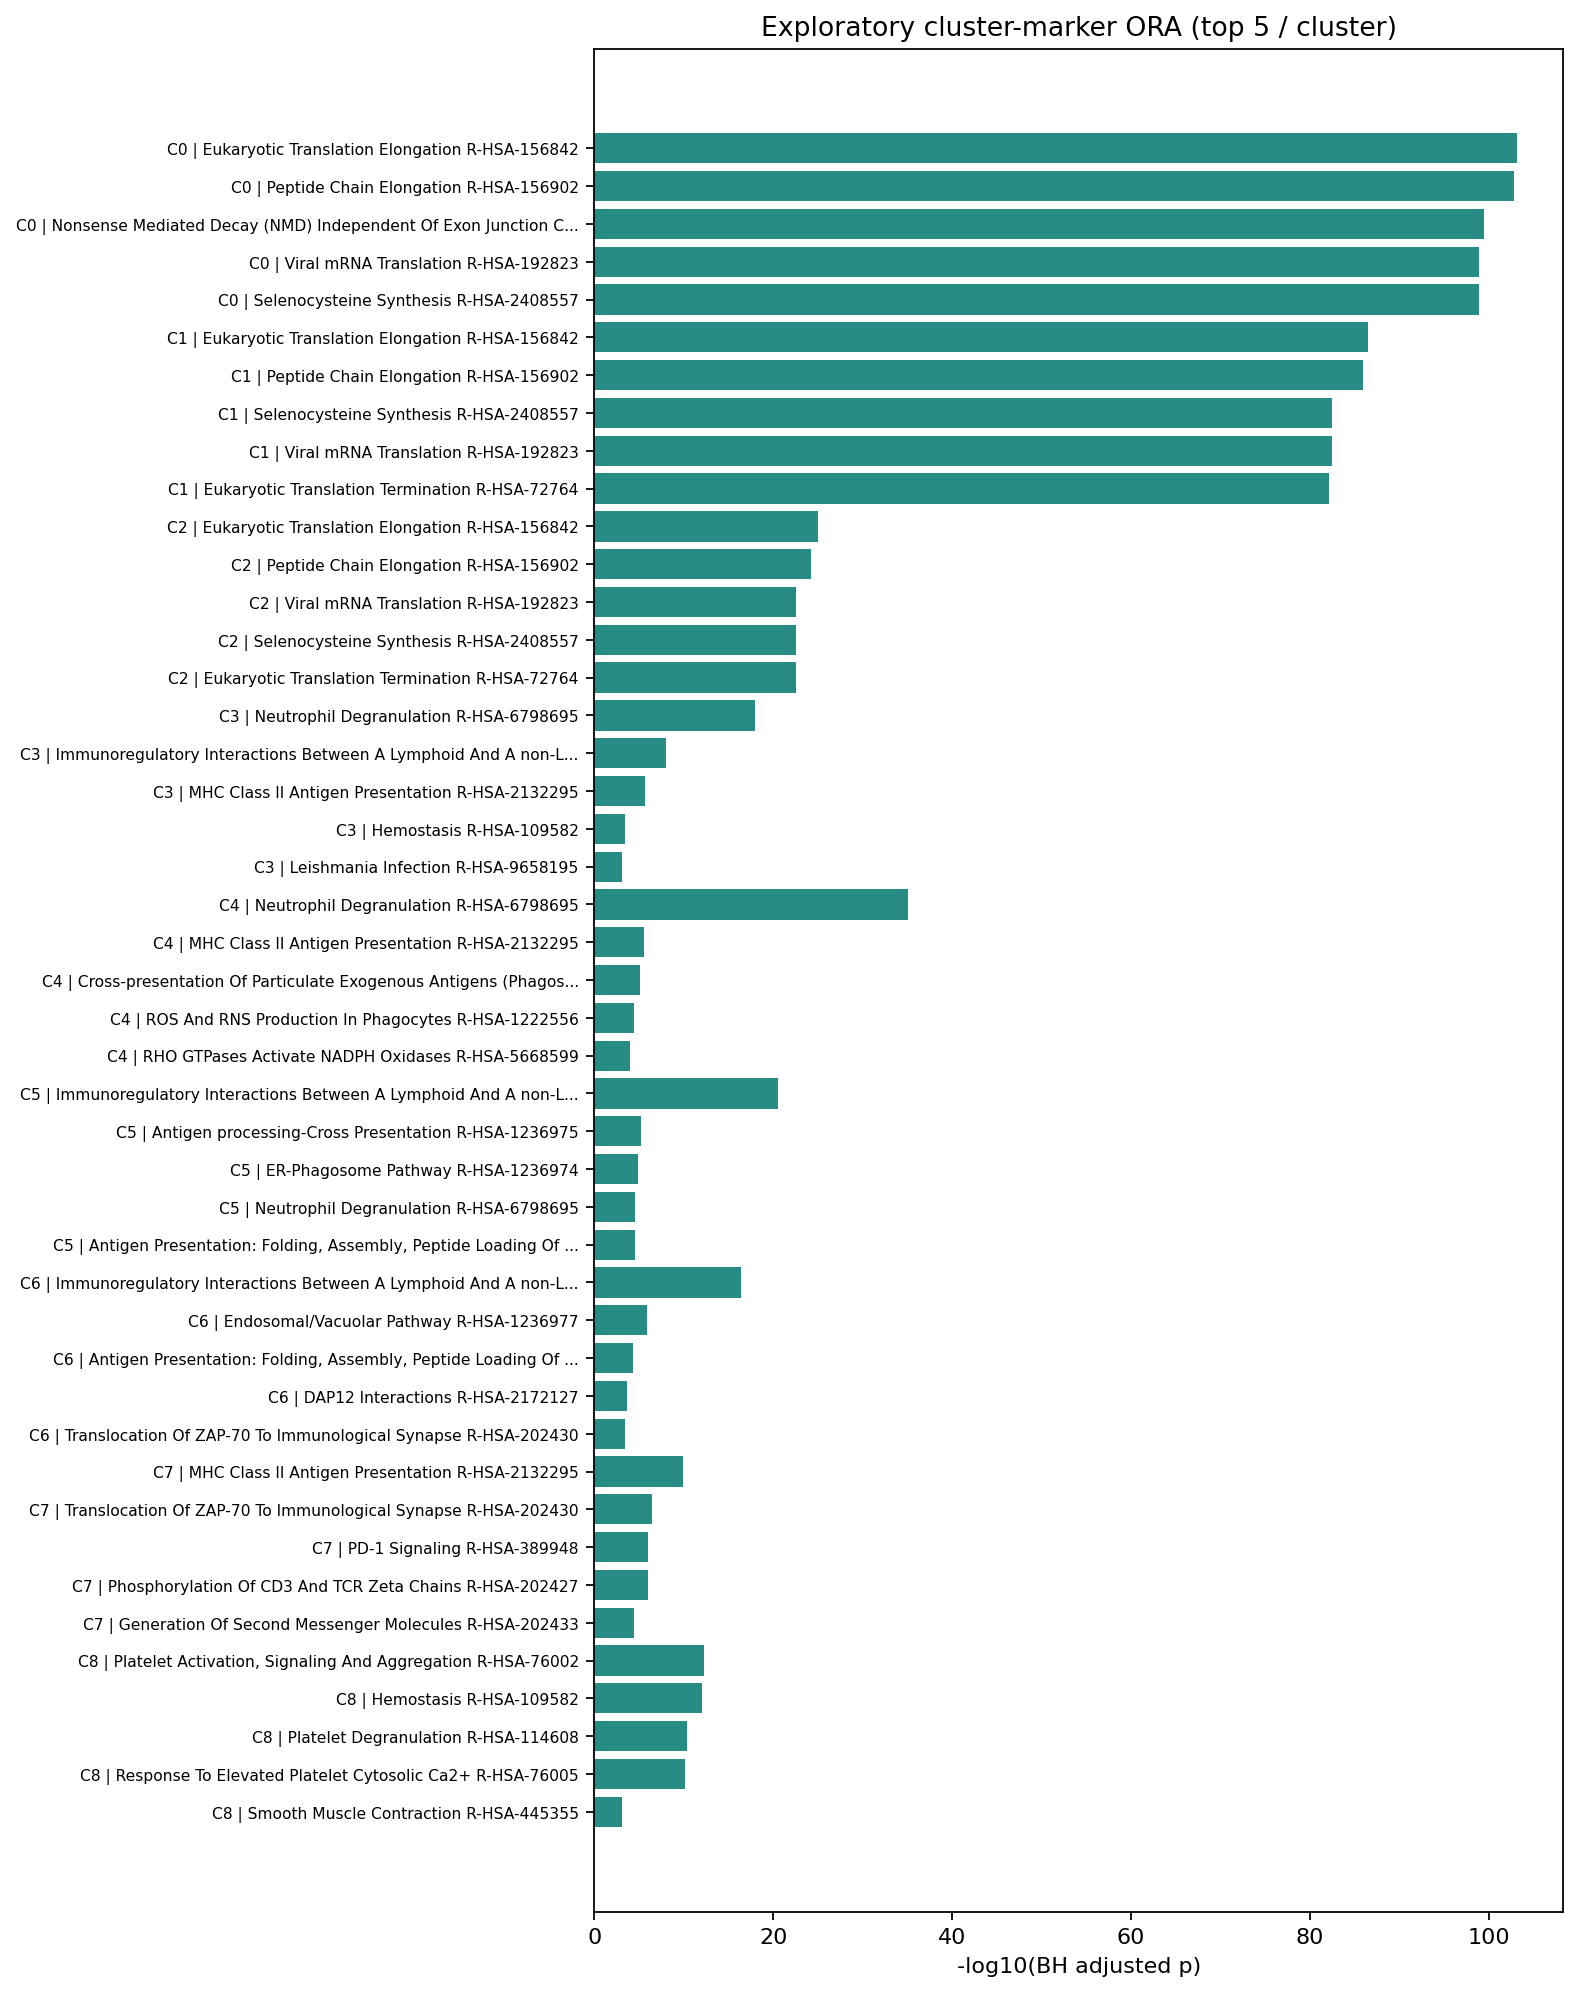

In [8]:
run_stage('enrichment', cfg)
display(pd.read_csv(out / 'tables/enrichment_top.csv').head(20))
fig = out / 'figures/enrichment.png'
if fig.exists():
    display(Image(filename=str(fig)))

## 8. 保存报告并检查可复现性

报告自带图片，可离线打开。配置、软件版本、输入摘要与阶段输出均被记录。
下面核对最终对象中的 counts 层确实来自原始输入。

In [9]:
run_stage('report', cfg)
final = sc.read_h5ad(out / 'objects/06_annotated.h5ad')
expected = counts[final.obs_names, final.var_names].X
assert (final.layers['counts'] != expected).nnz == 0
assert np.isfinite(final.obsm['X_umap']).all()
print('原始 UMI 保存验证通过；UMAP 坐标有效。')
print('报告:', str(out / 'report.html'))
display(pd.Series(json.loads((out / 'run_summary.json').read_text())))

[report] start
[report] completed in 0.8s
原始 UMI 保存验证通过；UMAP 坐标有效。
报告: results/notebook_pbmc3k/report.html


input_cells                                                       2700
retained_cells                                                    2607
input_genes                                                      32738
retained_genes                                                   13611
samples                                                              1
clusters                                                             9
hvg                                                               2000
donors                                                               1
cluster_sizes        {'0': 453, '1': 717, '2': 327, '3': 207, '4': ...
annotation_status                          [candidate_requires_review]
cell_type_counts     {'T cells': 1170, 'CD14 monocytes': 418, 'B ce...
qc_per_sample        [{'sample_id': 'pbmc3k', 'before': 2700, 'afte...
dtype: object

## 完成后做三个练习

1. 选择一个 cluster，写出支持和反对其候选标签的 marker 证据。
2. 将分辨率改为 0.5，并使用另一个输出目录，比较合并后的细胞群，而不是比较编号。
3. 解释为什么一个供者的 2,607 个保留细胞不能成为病例对照研究中的 2,607 个独立样本。

进阶入口见 `docs/04_multisample.md`；FASTQ 上游见 `docs/05_fastq.md`；R/Seurat 对应关系见 `docs/07_seurat_mapping.md`。